# Lecture 04 — Email spam classification

**Module:** OMC9000UK7 · Principles and Applications of Artificial Intelligence and Machine Learning  
**Programme:** MSc AI and Machine Learning · Gulf College  
**Lecture:** 04 — Introduction to Machine Learning and Data Mining  
**Topic:** Classification · **Learning outcome emphasis:** MLO1 and MLO3 (with MLO4 preparation through technique selection)

## Learning objective
Implement Multinomial Naive Bayes and evaluate binary spam predictions on unseen messages.

## Practical problem
Train on simplified synthetic email text and estimate whether new messages are spam.

## Dataset and transparency
The file **`dataset.csv`** was simulated for teaching. It is not collected from real people, businesses, medical systems or physical devices. Names/values are illustrative; models must not be deployed or used for real eligibility, employment, financial, clinical or safety decisions. A fixed random seed makes the example reproducible.

**How to run:** keep this notebook and `dataset.csv` in the same folder, then run all cells from top to bottom. If needed, install the packages listed in the collection’s `requirements.txt`.

**Assumptions:** The messages use class-skewed word pools with overlapping vocabulary and random noise. Actual email messages are much more varied than this simplified simulation.

## 1. Load the dataset and understand the variables
Always inspect several rows, column names, types, and possible missing values before choosing a model.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (7.2, 4.5), 'axes.grid': True, 'grid.alpha': .22})
DATA_FILE = Path('dataset.csv')
assert DATA_FILE.exists(), 'Place dataset.csv next to the notebook.'
df = pd.read_csv(DATA_FILE)
print(f'Dataset: {len(df):,} rows × {df.shape[1]} columns')
display(df.head())

Dataset: 620 rows × 2 columns


,message,is_spam
0,notification important information offer prize...,1
1,voucher please thanks message colleague reply,1
2,college meeting link information,0
3,contact details winner today,1
4,reward please information next bonus schedule ...,0


In [2]:
print('Columns:', df.columns.tolist())
print('Missing values per column:')
print(df.isna().sum().to_string())

Columns: ['message', 'is_spam']
Missing values per column:
message    0
is_spam    0


## 2. Visualise and formulate the task
**Question:** Which available columns are inputs (features), and which column is the class label? A classification problem predicts a *category*, not a continuous number.

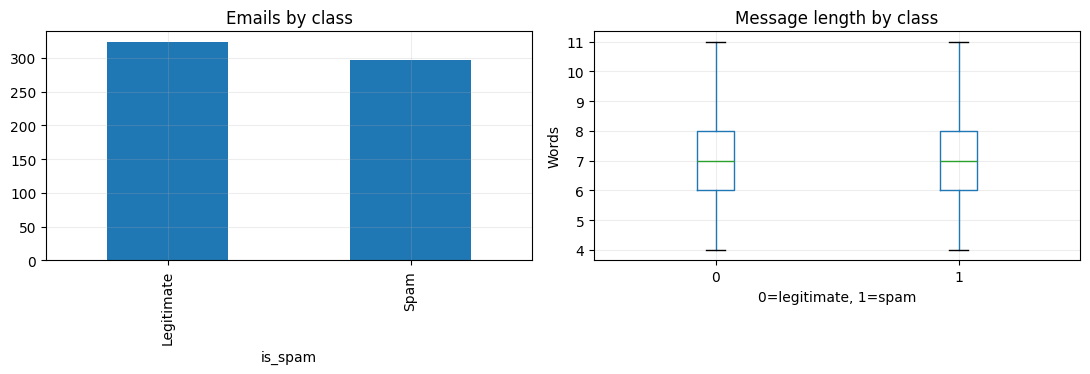

In [3]:
fig,ax=plt.subplots(1,2,figsize=(11,4))
df['is_spam'].map({0:'Legitimate',1:'Spam'}).value_counts().plot.bar(ax=ax[0]);ax[0].set_title('Emails by class')
df.assign(word_count=df['message'].str.split().str.len()).boxplot(column='word_count',by='is_spam',ax=ax[1]);ax[1].set(title='Message length by class',xlabel='0=legitimate, 1=spam',ylabel='Words');plt.suptitle('');plt.tight_layout();plt.show()

## 3. Prepare training and test data
The training set teaches the model. The test set simulates **unseen** examples. Split before fitting preprocessing transformations to avoid data leakage.

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['message'], df['is_spam'], test_size=.25, random_state=42, stratify=df['is_spam'])
print('Train:',len(X_train),'Test:',len(X_test))

Train: 465 Test: 155


## 4. Train Multinomial Naive Bayes
The model converts messages into word counts and then learns the likelihood of those words in spam and non-spam. The training vocabulary must be fitted **only on training messages**.

In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
model = make_pipeline(CountVectorizer(ngram_range=(1,2)),MultinomialNB(alpha=1))
model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('countvectorizer', ...), ('multinomialnb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


## 5. Evaluate precision, recall, accuracy and confusion matrix
Spam detection needs careful false-positive control: an important genuine message wrongly classified as spam can be costly.

Accuracy: 0.916
Precision (spam): 0.886
Recall (spam): 0.946
              precision    recall  f1-score   support

           0       0.95      0.89      0.92        81
           1       0.89      0.95      0.92        74

    accuracy                           0.92       155
   macro avg       0.92      0.92      0.92       155
weighted avg       0.92      0.92      0.92       155



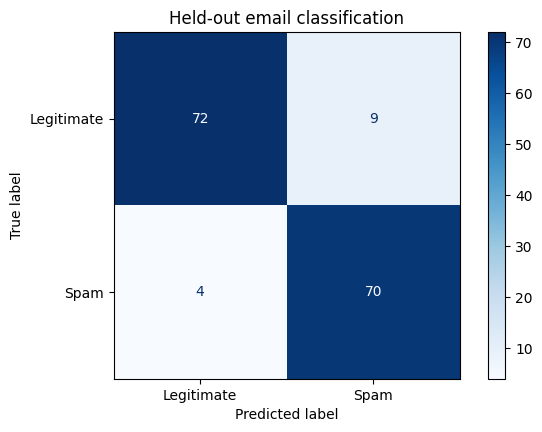

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, ConfusionMatrixDisplay
pred=model.predict(X_test)
print('Accuracy:',round(accuracy_score(y_test,pred),3))
print('Precision (spam):',round(precision_score(y_test,pred,zero_division=0),3))
print('Recall (spam):',round(recall_score(y_test,pred,zero_division=0),3))
print(classification_report(y_test,pred,zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test,pred,cmap='Blues',display_labels=['Legitimate','Spam'])
plt.title('Held-out email classification');plt.grid(False);plt.show()

## 6. Predict the category of new messages

In [7]:
messages=['urgent claim free prize today','please review the meeting report','exclusive offer on project management course']
results=pd.DataFrame({'message':messages,'spam_prediction':model.predict(messages),'spam_probability':model.predict_proba(messages)[:,1].round(3)})
display(results)

,message,spam_prediction,spam_probability
0,urgent claim free prize today,1,0.999
1,please review the meeting report,0,0.004
2,exclusive offer on project management course,0,0.426


## Student investigation and discussion
1. Why are word counts a reasonable text representation?
2. What is the cost of a false positive for a college inbox?
3. Why would a model trained on simulated vocabulary struggle with real emails?

**Reflect:** What assumption makes this classroom dataset easier than the equivalent real-world problem?

## References and further learning
- Russell, S. J., & Norvig, P. (2021). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.
- Mitchell, T. M. (1997). *Machine Learning*. McGraw-Hill.
- scikit-learn User Guide: https://scikit-learn.org/stable/user_guide.html
- Course connection: Lecture 04, OMC9000UK7, supervised/unsupervised learning, modelling workflow and evaluation.